In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
gdp = pd.read_csv('API_NY.GDP.PCAP.CD_DS2_en_csv_v2_245.csv', skiprows=4)

print(gdp.head())

                  Country Name Country Code                Indicator Name  \
0                        Aruba          ABW  GDP per capita (current US$)   
1  Africa Eastern and Southern          AFE  GDP per capita (current US$)   
2                  Afghanistan          AFG  GDP per capita (current US$)   
3   Africa Western and Central          AFW  GDP per capita (current US$)   
4                       Angola          AGO  GDP per capita (current US$)   

   Indicator Code        1960        1961        1962        1963        1964  \
0  NY.GDP.PCAP.CD         NaN         NaN         NaN         NaN         NaN   
1  NY.GDP.PCAP.CD  186.089204  186.909053  197.367547  225.400079  208.962717   
2  NY.GDP.PCAP.CD         NaN         NaN         NaN         NaN         NaN   
3  NY.GDP.PCAP.CD  121.936832  127.451040  133.823783  139.004980  148.545883   
4  NY.GDP.PCAP.CD         NaN         NaN         NaN         NaN         NaN   

         1965  ...          2017          2018    

In [3]:
#ensures we format data by country rather than year
gdp_long = gdp.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=[str(y) for y in range(2010, 2024)],
    var_name='year',
    value_name='gdp_per_capita'
)

gdp_long['year'] = gdp_long['year'].astype(int)
gdp_long = gdp_long.dropna(subset=['gdp_per_capita'])
gdp_long.columns = ['country_name', 'country_code', 'year', 'gdp_per_capita']

print(gdp_long.head())

                  country_name country_code  year  gdp_per_capita
0                        Aruba          ABW  2010    24093.140151
1  Africa Eastern and Southern          AFE  2010     1628.905248
2                  Afghanistan          AFG  2010      560.621505
3   Africa Western and Central          AFW  2010     1662.633658
4                       Angola          AGO  2010     4101.637156


In [4]:
removals = pd.read_csv('removals_10yr.csv', usecols=['Departure Country', 'Departure Date'])

removals['year'] = pd.to_datetime(removals['Departure Date'], errors='coerce').dt.year

removals_by_country = removals.groupby(['Departure Country', 'year']).size().reset_index(name='removal_count')

print(removals_by_country.head())

  Departure Country  year  removal_count
0       AFGHANISTAN  2011              5
1       AFGHANISTAN  2012             18
2       AFGHANISTAN  2013             10
3       AFGHANISTAN  2014             20
4       AFGHANISTAN  2015              4


In [5]:
removals_by_country['country_name'] = removals_by_country['Departure Country'].str.title()

merged_gdp = pd.merge(
    removals_by_country,
    gdp_long,
    on=['country_name', 'year'],
    how='inner'
)

print(merged_gdp.shape)
print(merged_gdp.head())

(1611, 6)
  Departure Country  year  removal_count country_name country_code  \
0       AFGHANISTAN  2011              5  Afghanistan          AFG   
1       AFGHANISTAN  2012             18  Afghanistan          AFG   
2       AFGHANISTAN  2013             10  Afghanistan          AFG   
3       AFGHANISTAN  2014             20  Afghanistan          AFG   
4       AFGHANISTAN  2015              4  Afghanistan          AFG   

   gdp_per_capita  
0      606.694676  
1      651.417134  
2      637.087099  
3      625.054942  
4      565.569730  


In [7]:
top10 = merged_gdp.groupby('country_name').agg(
    total_removals=('removal_count', 'sum'),
    avg_gdp=('gdp_per_capita', 'mean')
).nlargest(10, 'total_removals').reset_index()

print(top10)

         country_name  total_removals       avg_gdp
0              Mexico         1534414  10217.719766
1           Guatemala          383620   4011.157443
2            Honduras          268805   2314.726675
3         El Salvador          178090   3902.914855
4  Dominican Republic           21070   7052.343931
5             Ecuador           16985   5951.266427
6              Brazil           16128  10171.131672
7           Nicaragua           12529   1974.326975
8            Colombia           11751   6865.055943
9               Haiti           11574   1426.948499


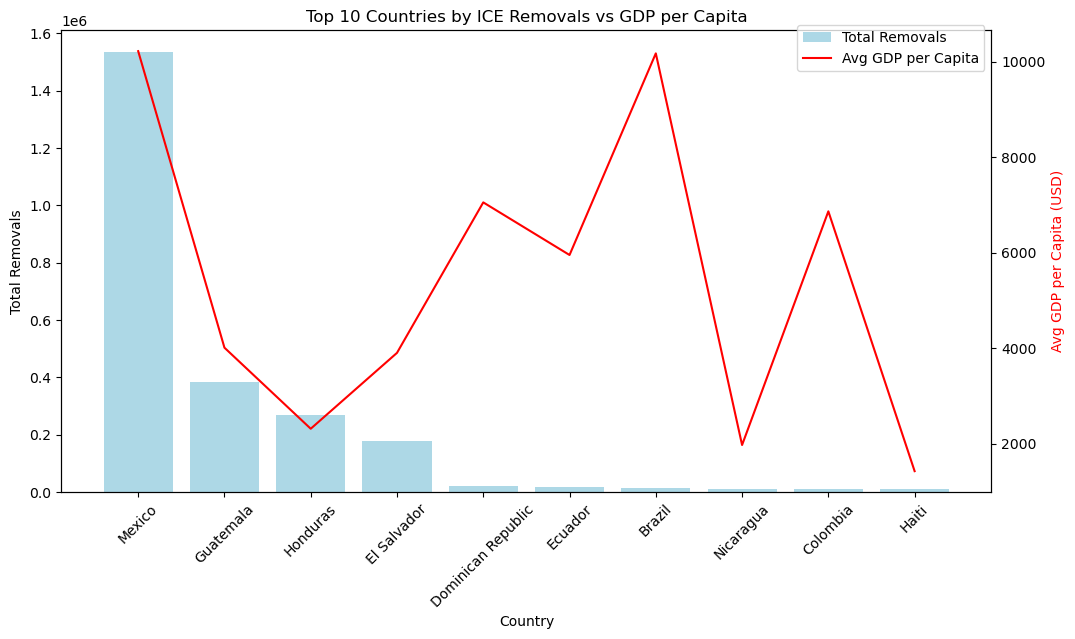

In [22]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(top10['country_name'], top10['total_removals'], color='lightblue', label='Total Removals')
ax1.set_xlabel('Country')
ax1.set_ylabel('Total Removals')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(top10['country_name'], top10['avg_gdp'], color='red', label='Avg GDP per Capita')
ax2.set_ylabel('Avg GDP per Capita (USD)', color='red')

plt.title('Top 10 Countries by ICE Removals vs GDP per Capita')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.show()

The top 10 countries by ICe removals are all Latin American with low GDP per capita. Mexico dominates with over 1.5 million removals and Guatemala, Honduras, and El Salvador following. Based on the chart it does not seem like GDP is a factor that changes immigration patterns since, for example, Mexico and Brazil both have a GDP per capita of around 10,000 USD but Mexico has significantly higher removals. This suggests that there are other factors such as geographic proximity to the US may matter just as much as economic conditions when it comes to who immigrates to the US.

Another important note to make is that we are utilizing the ICE removal data. While it does not capture the bigger picture of U.S. removals (for example, border removals or voluntary leave from the U.S. will not be taken into consideration) as it includes data about the country of origins.